In [5]:
from __future__ import print_function
import steps.model as smodel
import steps.solver as ssolver
import steps.geom as swm
import steps.rng as srng

from components import *

In [6]:
mdl = smodel.Model()

cytVolVal = 8.2e-18 # cyt vol = 8.2 um^3
cytArea = 8.5e-12 # cyt surf area = 8.5 um^2

cytssys = smodel.Surfsys('cytSurfsys', mdl)

Ca = smodel.Spec('Ca', mdl)
get_AZ(cytssys, mdl, Ca)

wmgeom = swm.Geom()

# Create the cytosol compartment
cytVol = swm.Comp('cytVol', wmgeom, vol=cytVolVal) # cyt vol = 1 - ER vol = 0.961 um^3
#cytVol.addVolsys('cytvsys')

# cyt is the 'inner' compartment, no outer compartment
cytSurf = swm.Patch('cytSurf', wmgeom, cytVol, area=cytArea) # cyt surf area = 8.5 um^2
cytSurf.addSurfsys('cytSurfsys')

r = srng.create('mt19937', 256)
r.initialize(23411)

sim = ssolver.Wmdirect(mdl, wmgeom, r)

In [7]:
sim.reset()

### Simulation time
ti, tf, dt = 0.0, 100.0e-3, 1e-4
T = np.arange(ti, tf+dt, dt)
npts = len(T)

### Set initial conditions
sim.setCompConc('cytVol', 'Ca', 1e-6) #initV['Ca'][0])
sim.setPatchCount('cytSurf', 'AZ00', 7)

resCa = np.zeros([npts])
resAZ = np.zeros([npts, len(azMolName)])

vesRel = np.zeros([npts, 10])

vesRelReac = ['R_synAZ50', 'R_synAZ51', 'R_synAZ52', 'R_asynAZ02', 'R_asynAZ12',
              'R_asynAZ22', 'R_asynAZ32', 'R_asynAZ42', 'R_asynAZ52', 'R_dAZ00']

Ti = time()
for t in range(npts):
    sim.run(T[t])
    

    sim.setCompConc('cytVol', 'Ca', t*1e-6/npts)
        
    resCa[t] = sim.getCompCount('cytVol', 'Ca')
    
    for i,reac in enumerate(vesRelReac):
        vesRel[t,i] = sim.getPatchSReacExtent('cytSurf', reac)
        
    for i,mol in enumerate(azMolName):
        resAZ[t,i] = sim.getPatchCount('cytSurf', mol)

Tf = time()
print(Tf-Ti, 'sec')

0.3786745071411133 sec


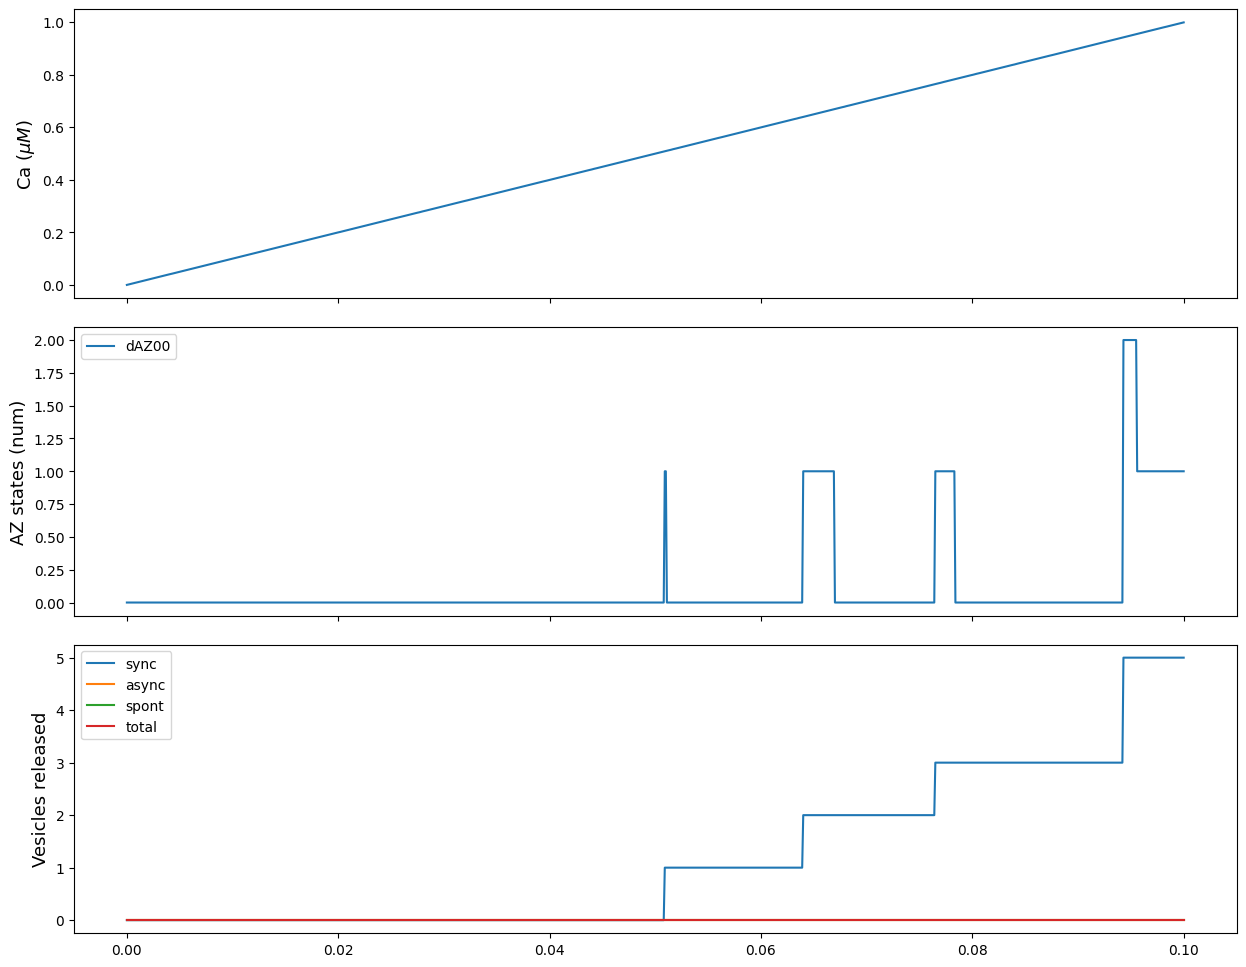

In [8]:
nFig = 3
figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True)
figure.subplots_adjust(hspace=0.1)
labelfontsize = 13

ax[0].plot(T, resCa/NA/cytVolVal*1e3, label='Ca')
ax[0].set_ylabel(r'Ca ($\mu M$)', fontsize=labelfontsize)

for mol in azMolName[18:19]:
    i = azMolName.index(mol)
    ax[1].plot(T, resAZ[:,i], label=mol)
ax[1].set_ylabel('AZ states (num)', fontsize=labelfontsize)
ax[1].legend()

vesRelSync  = np.sum(vesRel[:,:3], axis=1)
vesRelAsync = np.sum(vesRel[:,3:-1], axis=1)
vesRelSpont = vesRel[:,-1]
vesRelTot   = np.sum(vesRel[:,:], axis=1)

ax[2].plot(T, vesRelSync, label='sync')
ax[2].plot(T, vesRelAsync, label='async')
ax[2].plot(T, vesRelSpont, label='spont')
ax[2].plot(T, vesRelSpont, label='total')
    
ax[2].set_ylabel('Vesicles released', fontsize=labelfontsize)
ax[2].legend()

plt.show()